# 00 — Data inspection

Inspect raw ECG data. Implement `load_raw_dataset()` in `src/data/io.py` before running the load cell.

## Setup

Configure logging and ensure the notebook imports code from this project (not another copy elsewhere on the system).

In [2]:
from pathlib import Path
import sys
from src.data.io import load_raw_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

# Project root = parent of notebooks/
PROJECT_ROOT = Path.cwd().resolve().parents[0]

# Make sure our repo root is searched FIRST
project_root_str = str(PROJECT_ROOT)
if project_root_str in sys.path:
    sys.path.remove(project_root_str)
sys.path.insert(0, project_root_str)

print("Using PROJECT_ROOT:", PROJECT_ROOT)
print("sys.path[0]:", sys.path[0])

import src.data.io as io
from src.data.io import load_raw_dataset

print("src.data.io file:", io.__file__)

Using PROJECT_ROOT: C:\Projects\DeepLearningProject
sys.path[0]: C:\Projects\DeepLearningProject
src.data.io file: C:\Users\jacob\OneDrive\Documents\School\Spring 2026\Deep Learning Project\src\data\io.py


## Load data (rebuild cache)

Load the ECG dataset from the raw WFDB files, deleting any existing cache and rebuilding it from scratch. This step parses all recordings, constructs the signal and label arrays, and saves a new cached copy for faster future loading. The printed shapes confirm that the data loaded successfully and match the expected dimensions.

In [3]:
X, y = load_raw_dataset(force_reload = False)

print("X shape:", X.shape)
print("y shape:", y.shape)

2026-03-12 20:53:22,323 | WARNING | Cache file corrupt or unreadable (BadZipFile). Rebuilding from raw: File is not a zip file
2026-03-12 20:53:22,325 | WARNING | Could not delete corrupt cache (file in use, e.g. by OneDrive). Rebuilding from raw; new cache will overwrite when save runs. [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\jacob\\OneDrive\\Documents\\School\\Spring 2026\\Deep Learning Project\\data\\processed\\chapman_wfdb_Xy.npz'
2026-03-12 20:53:22,753 | INFO | Stage 1/4 — Loading raw WFDB files (45152 records)
2026-03-12 20:53:38,680 | INFO | Loading progress 4516/45152 (10%) | 284 rec/s | ETA 143s | kept 4515
2026-03-12 20:53:46,040 | INFO | Loading progress 9031/45152 (20%) | 388 rec/s | ETA 93s | kept 9030
2026-03-12 20:53:53,320 | INFO | Loading progress 13546/45152 (30%) | 443 rec/s | ETA 71s | kept 13545
2026-03-12 20:54:00,947 | INFO | Loading progress 18061/45152 (40%) | 473 rec/s | ETA 57s | kept 18060
20

X shape: (45150, 12, 5000)
y shape: (45150, 4)


# Exploration


In [4]:
CLASS_NAMES = [
    "Atrial\nFibrillation",
    "Supraventricular\nTachycardia",
    "Sinus\nBradycardia",
    "Sinus\nRhythm",
]

## Dataset overview

Report the basic structure of the dataset, including the number of recordings, number of ECG leads, samples per recording, and approximate signal duration (assuming a 500 Hz sampling rate).

In [5]:
N, n_leads, T = X.shape

print(f"Recordings: {N}")
print(f"Leads: {n_leads}")
print(f"Samples per lead: {T}")
print(f"Duration @500 Hz: {T/500:.2f} sec")

Recordings: 45150
Leads: 12
Samples per lead: 5000
Duration @500 Hz: 10.00 sec


## Label distribution

Compute the number of recordings associated with each target class to assess class balance and identify any heavily under- or over-represented diagnoses.

In [6]:
class_counts = y.sum(axis=0)
counts = pd.Series(class_counts)

counts

0     1780
1     1091
2    16559
3     8125
dtype: int32

In [ ]:
# Meta-class totals (11 rhythms merged into 4 groups); multi-label so sum can exceed N
from src.data.io import CLASS_NAMES as META_NAMES
counts_per_class = y.sum(axis=0)
n_total = len(y)
print("Total samples:", n_total)
print("\nCount (and % of samples) in each meta-class:")
for name, c in zip(META_NAMES, counts_per_class):
    pct = 100.0 * c / n_total
    print(f"  {name}: {int(c)} ({pct:.1f}%)")
print("\n(Sum of counts can exceed total because a sample can have multiple labels.)")

## Class distribution (visual)

Visualize the number of recordings in each target class using a bar chart to highlight class imbalance and relative prevalence across diagnoses.

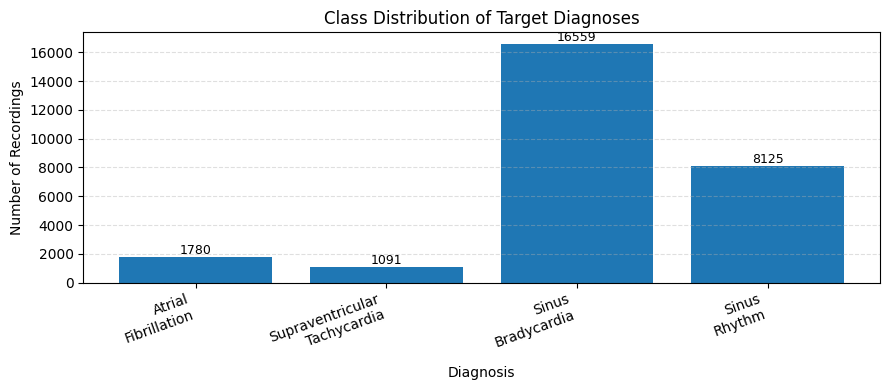

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(CLASS_NAMES, counts.values)

ax.set_title("Class Distribution of Target Diagnoses")
ax.set_ylabel("Number of Recordings")
ax.set_xlabel("Diagnosis")

ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## Label co-occurrence

Compute and visualize how often pairs of diagnoses appear together across recordings, providing insight into relationships between classes in this multilabel dataset.

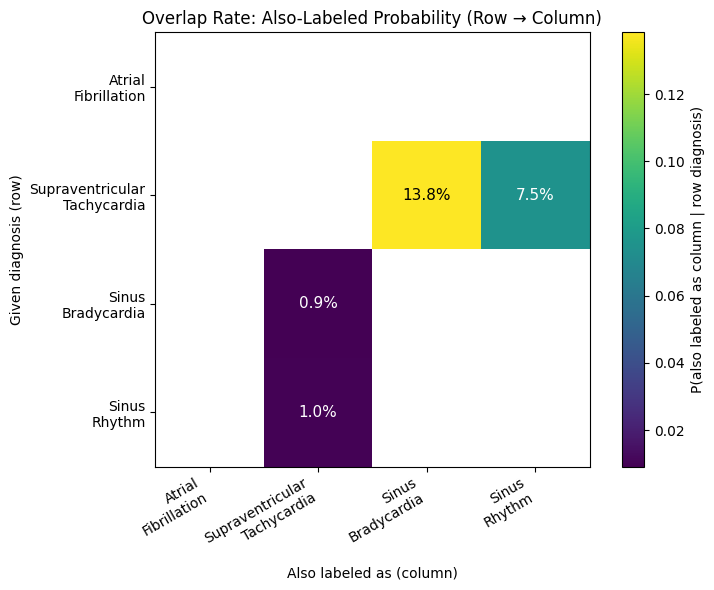

In [8]:
co_occurrence = y.astype(np.int32).T @ y.astype(np.int32)

diag = co_occurrence.diagonal()
cond = co_occurrence / diag[:, None]  # P(column | row)

M = cond.copy()
np.fill_diagonal(M, np.nan)
M[M < 0.005] = np.nan  # hide tiny overlaps (<0.5%)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(M, aspect="equal")

ax.set_title("Overlap Rate: Also-Labeled Probability (Row → Column)")
ax.set_xlabel("Also labeled as (column)")
ax.set_ylabel("Given diagnosis (row)")

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticklabels(CLASS_NAMES)

# Auto-contrast based on the *rendered* cell color (RGBA luminance)
# This matches what you actually see on screen.
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        val = M[i, j]
        if np.isnan(val):
            continue

        rgba = im.cmap(im.norm(val))
        r, g, b, _ = rgba
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b  # perceived brightness
        txt_color = "black" if luminance > 0.6 else "white"

        ax.text(
            j, i, f"{val:.1%}",
            ha="center", va="center",
            fontsize=11,
            color=txt_color
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("P(also labeled as column | row diagnosis)")

plt.tight_layout()
plt.show()

## Example signals

Display one randomly selected recording across all leads to visually confirm that the waveforms appear physiologically plausible and correctly aligned.

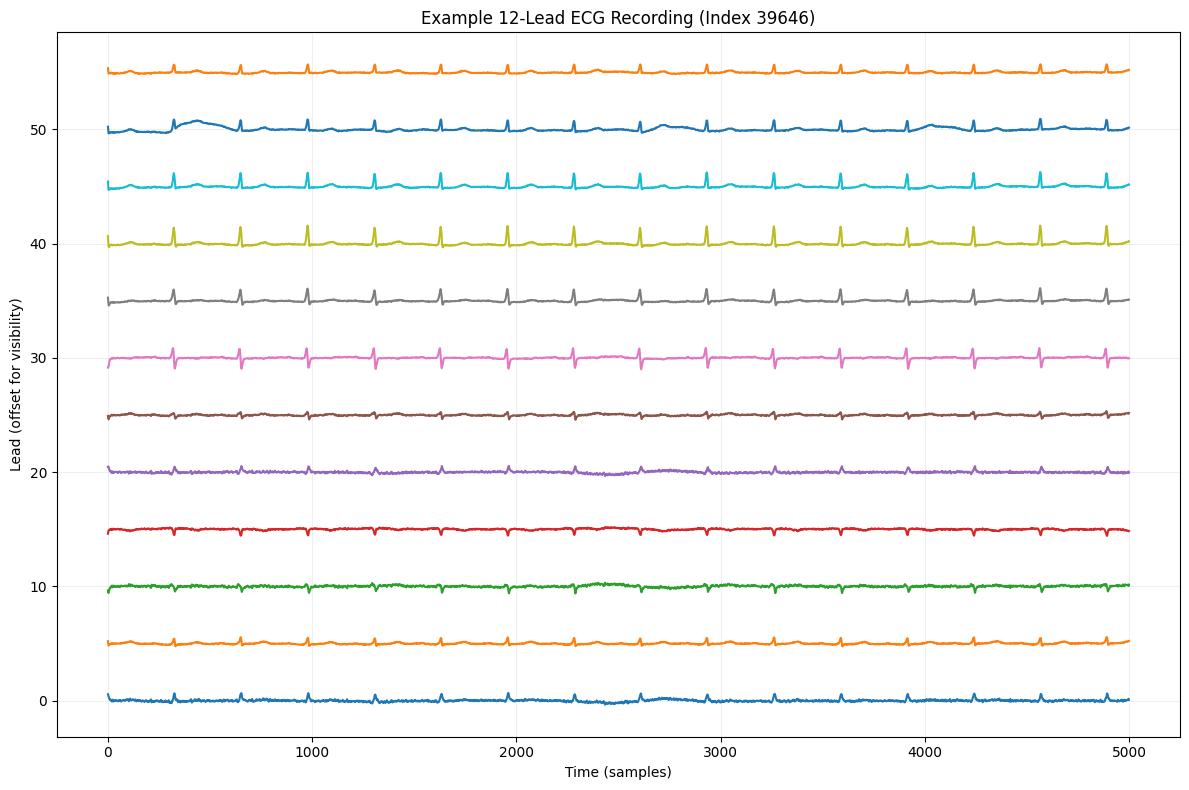

In [9]:
idx = np.random.randint(0, N)
sample = X[idx]

plt.figure(figsize=(12, 8))

offset = 5

for i in range(n_leads):
    plt.plot(sample[i] + i * offset)

plt.title(f"Example 12-Lead ECG Recording (Index {idx})")
plt.xlabel("Time (samples)")
plt.ylabel("Lead (offset for visibility)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 12×4 ECG by condition (mean ± 95% CI)

For each of the four conditions, take up to 100 recordings and plot the average waveform per lead with 95% confidence intervals. One column per condition, one row per lead.

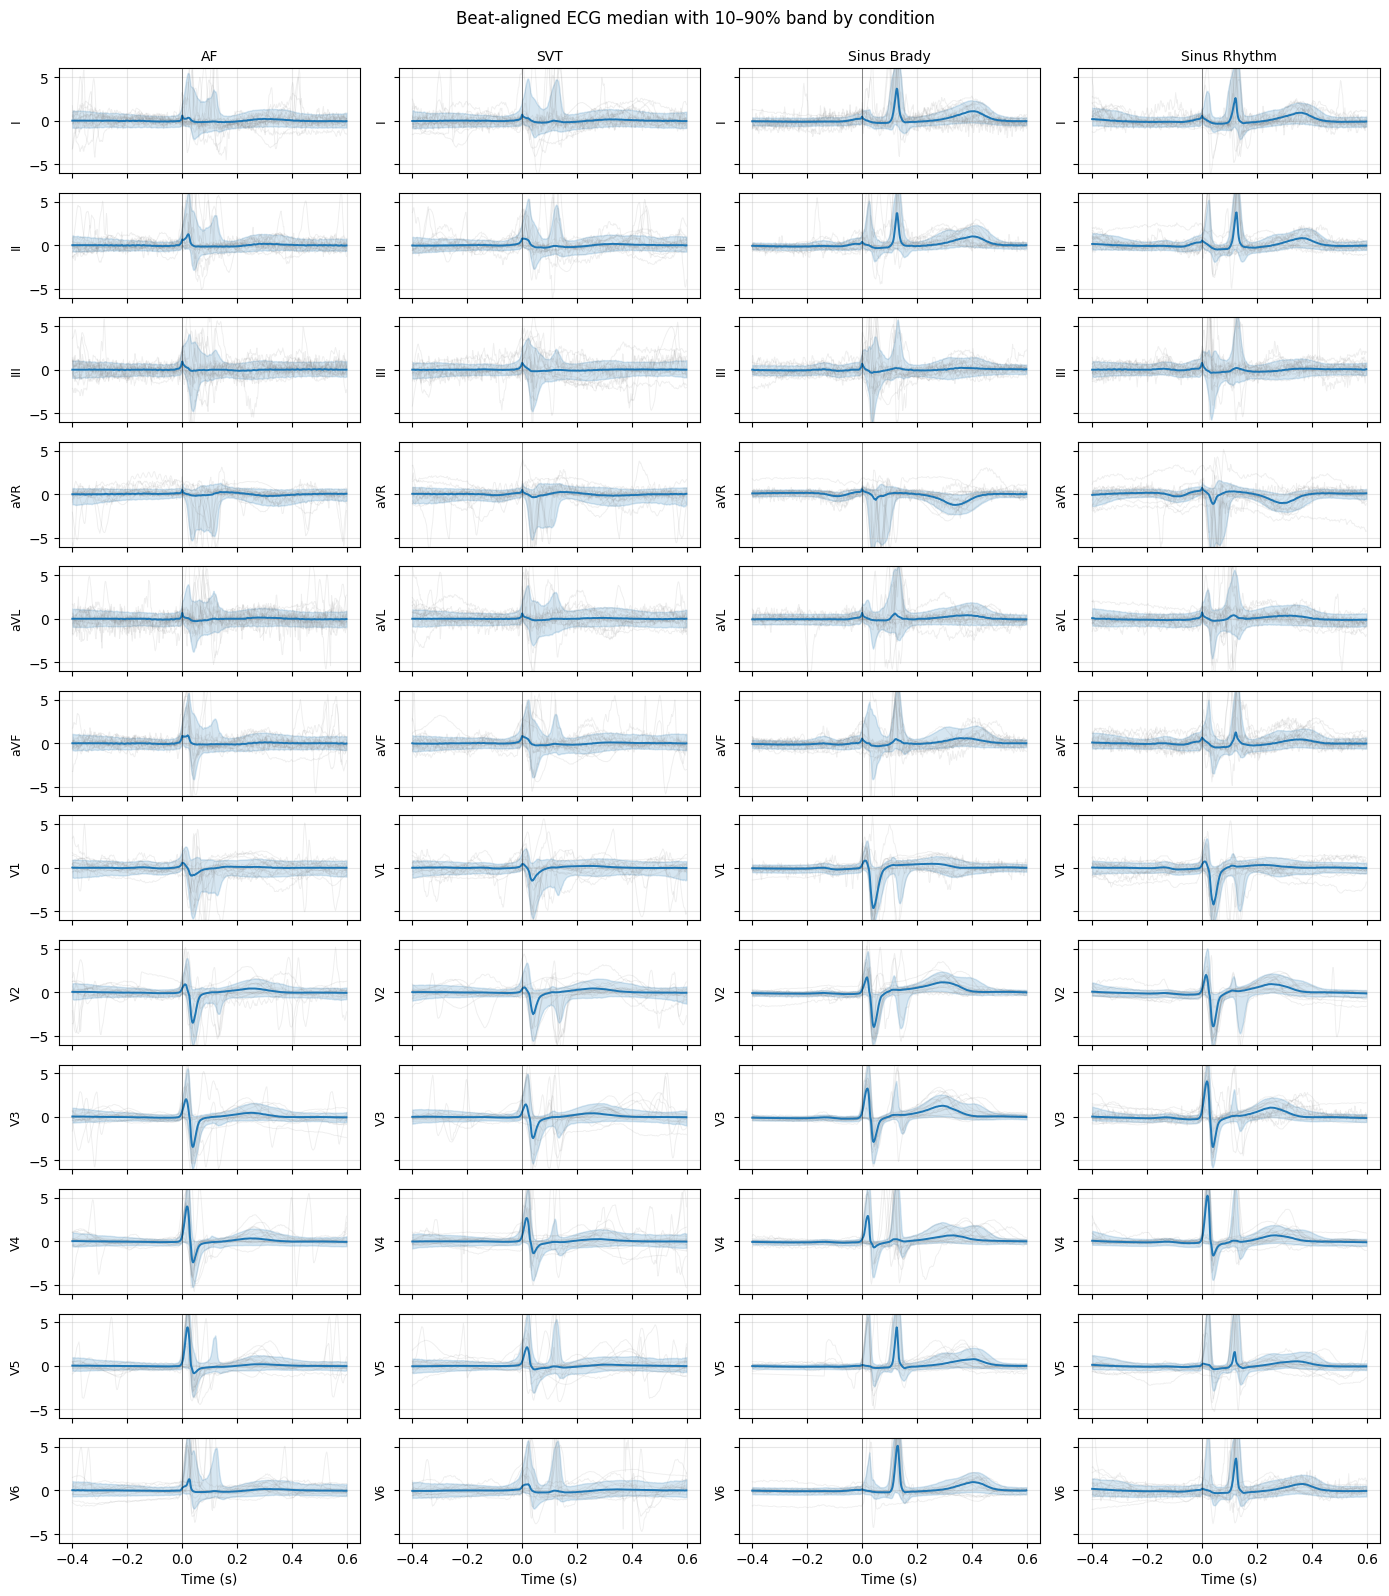

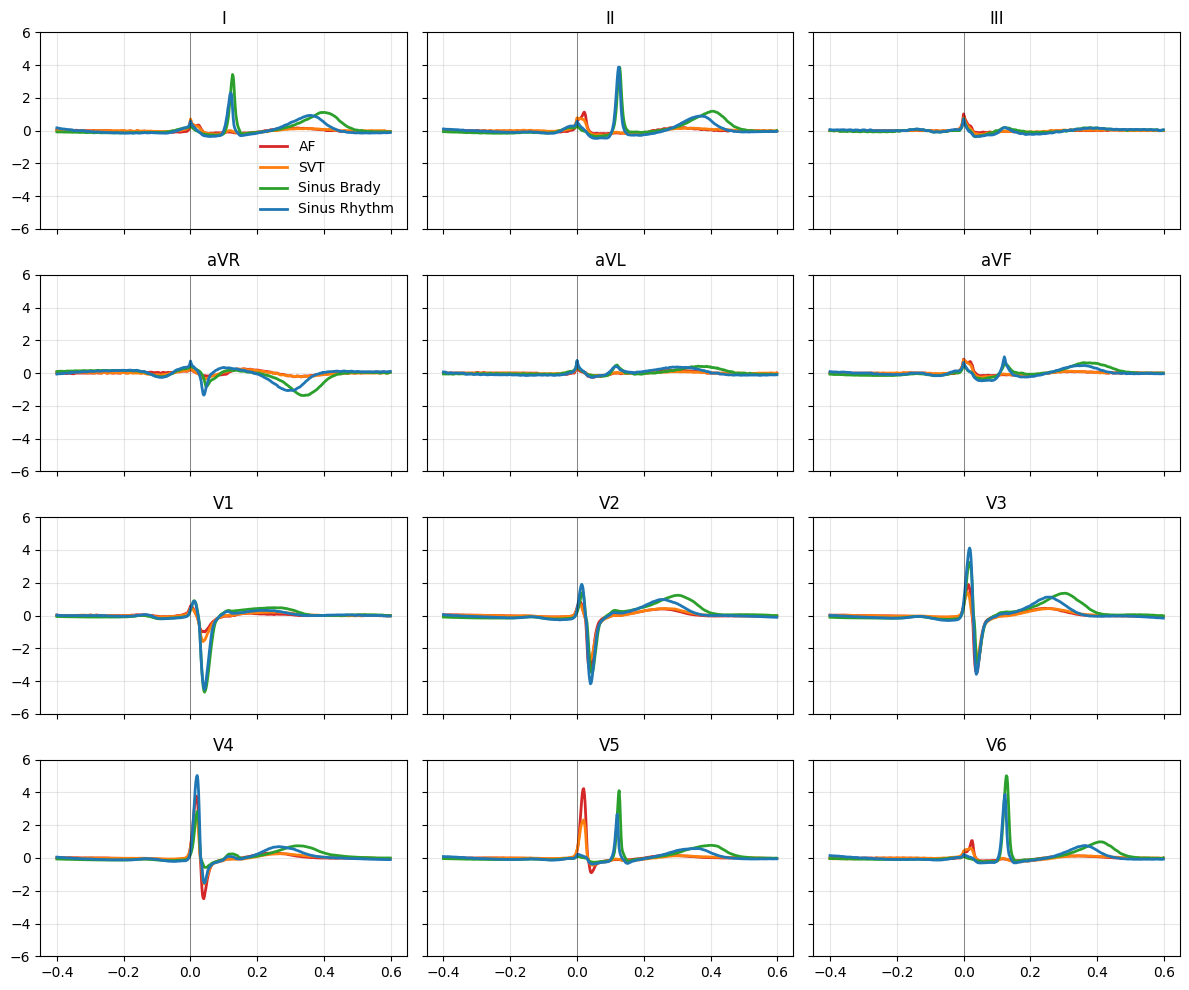

In [13]:
from src.data.io import CLASS_NAMES as CONDITION_NAMES
import numpy as np
import matplotlib.pyplot as plt

LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

N_SAMPLES_PER_CONDITION = 500
MAX_BEATS_PER_RECORD = 8
FS = 500

def detect_r_peaks(sig, fs=500):
    d = np.diff(sig)
    sq = d**2
    win = int(0.150 * fs)
    mwa = np.convolve(sq, np.ones(win)/win, mode="same")

    thr = np.mean(mwa) + 0.5*np.std(mwa)
    cand = np.where(mwa > thr)[0]

    if len(cand) == 0:
        return np.array([], dtype=int)

    peaks = []
    refractory = int(0.250 * fs)
    last = -refractory

    for i in cand:
        if i - last < refractory:
            continue

        start = max(i - int(0.05*fs), 0)
        end   = min(i + int(0.05*fs), len(sig))
        p = start + np.argmax(sig[start:end])

        peaks.append(p)
        last = p

    return np.array(peaks, dtype=int)


n_leads, T = X.shape[1], X.shape[2]

pre  = int(0.40 * FS)
post = int(0.60 * FS)
beat_T = pre + post

t_sec = (np.arange(beat_T) - pre) / FS

fig, axes = plt.subplots(
    12, 4,
    figsize=(14,16),
    sharex=True,
    sharey=True
)

fig.suptitle(
    "Beat-aligned ECG median with 10–90% band by condition",
    fontsize=12,
    y=0.995
)

rng = np.random.default_rng(0)

for col, cond in enumerate(range(4)):

    idx_cond = np.where(y[:, cond])[0]

    if len(idx_cond) == 0:
        for row in range(12):
            axes[row, col].set_visible(False)
        continue

    idx_cond = rng.choice(
        idx_cond,
        size=min(len(idx_cond), N_SAMPLES_PER_CONDITION),
        replace=False
    )

    for row in range(12):

        ax = axes[row, col]
        beats = []

        for i in idx_cond:

            sig = X[i, row, :]

            sig = sig - np.median(sig)

            r = detect_r_peaks(sig, FS)

            r = r[:MAX_BEATS_PER_RECORD]

            for rp in r:

                s = rp - pre
                e = rp + post

                if s < 0 or e >= T:
                    continue

                beat = sig[s:e]

                sd = np.std(beat)
                if sd > 0:
                    beat = beat / sd

                beats.append(beat)

        if len(beats) == 0:
            ax.set_visible(False)
            continue

        beats = np.stack(beats)

        lo  = np.percentile(beats, 10, axis=0)
        hi  = np.percentile(beats, 90, axis=0)
        med = np.median(beats, axis=0)

        draw = rng.choice(len(beats), size=min(15, len(beats)), replace=False)

        for d in draw:
            ax.plot(
                t_sec,
                beats[d],
                color="gray",
                alpha=0.12,
                lw=0.7
            )

        ax.fill_between(
            t_sec,
            lo,
            hi,
            alpha=0.18,
            color="C0"
        )

        ax.plot(
            t_sec,
            med,
            lw=1.4,
            color="C0"
        )

        ax.axvline(
            0,
            color="black",
            lw=0.6,
            alpha=0.5
        )

        ax.set_ylim(-6, 6)

        ax.grid(True, alpha=0.3)

        ax.set_ylabel(
            LEAD_NAMES[row],
            fontsize=9
        )

        if row == 0:
            ax.set_title(
                CONDITION_NAMES[cond],
                fontsize=10
            )

        if row == 11:
            ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()



# --------------------------------------------------------
# SECOND FIGURE — CONDITION OVERLAY PER LEAD
# --------------------------------------------------------

colors = ["C3","C1","C2","C0"]

fig2, axes2 = plt.subplots(
    4, 3,
    figsize=(12,10),
    sharex=True,
    sharey=True
)

axes2 = axes2.flatten()

for row in range(12):

    ax = axes2[row]

    for cond in range(4):

        idx_cond = np.where(y[:, cond])[0]

        if len(idx_cond) == 0:
            continue

        idx_cond = rng.choice(
            idx_cond,
            size=min(len(idx_cond), N_SAMPLES_PER_CONDITION),
            replace=False
        )

        beats = []

        for i in idx_cond:

            sig = X[i, row, :]
            sig = sig - np.median(sig)

            r = detect_r_peaks(sig, FS)
            r = r[:MAX_BEATS_PER_RECORD]

            for rp in r:

                s = rp - pre
                e = rp + post

                if s < 0 or e >= T:
                    continue

                beat = sig[s:e]

                sd = np.std(beat)
                if sd > 0:
                    beat = beat / sd

                beats.append(beat)

        if len(beats) == 0:
            continue

        beats = np.stack(beats)

        med = np.median(beats, axis=0)

        ax.plot(
            t_sec,
            med,
            lw=2,
            color=colors[cond],
            label=CONDITION_NAMES[cond]
        )

    ax.axvline(0, color="black", lw=0.6, alpha=0.5)

    ax.set_title(LEAD_NAMES[row])

    ax.set_ylim(-6,6)

    ax.grid(True, alpha=0.3)

axes2[0].legend(frameon=False)

plt.tight_layout()
plt.show()

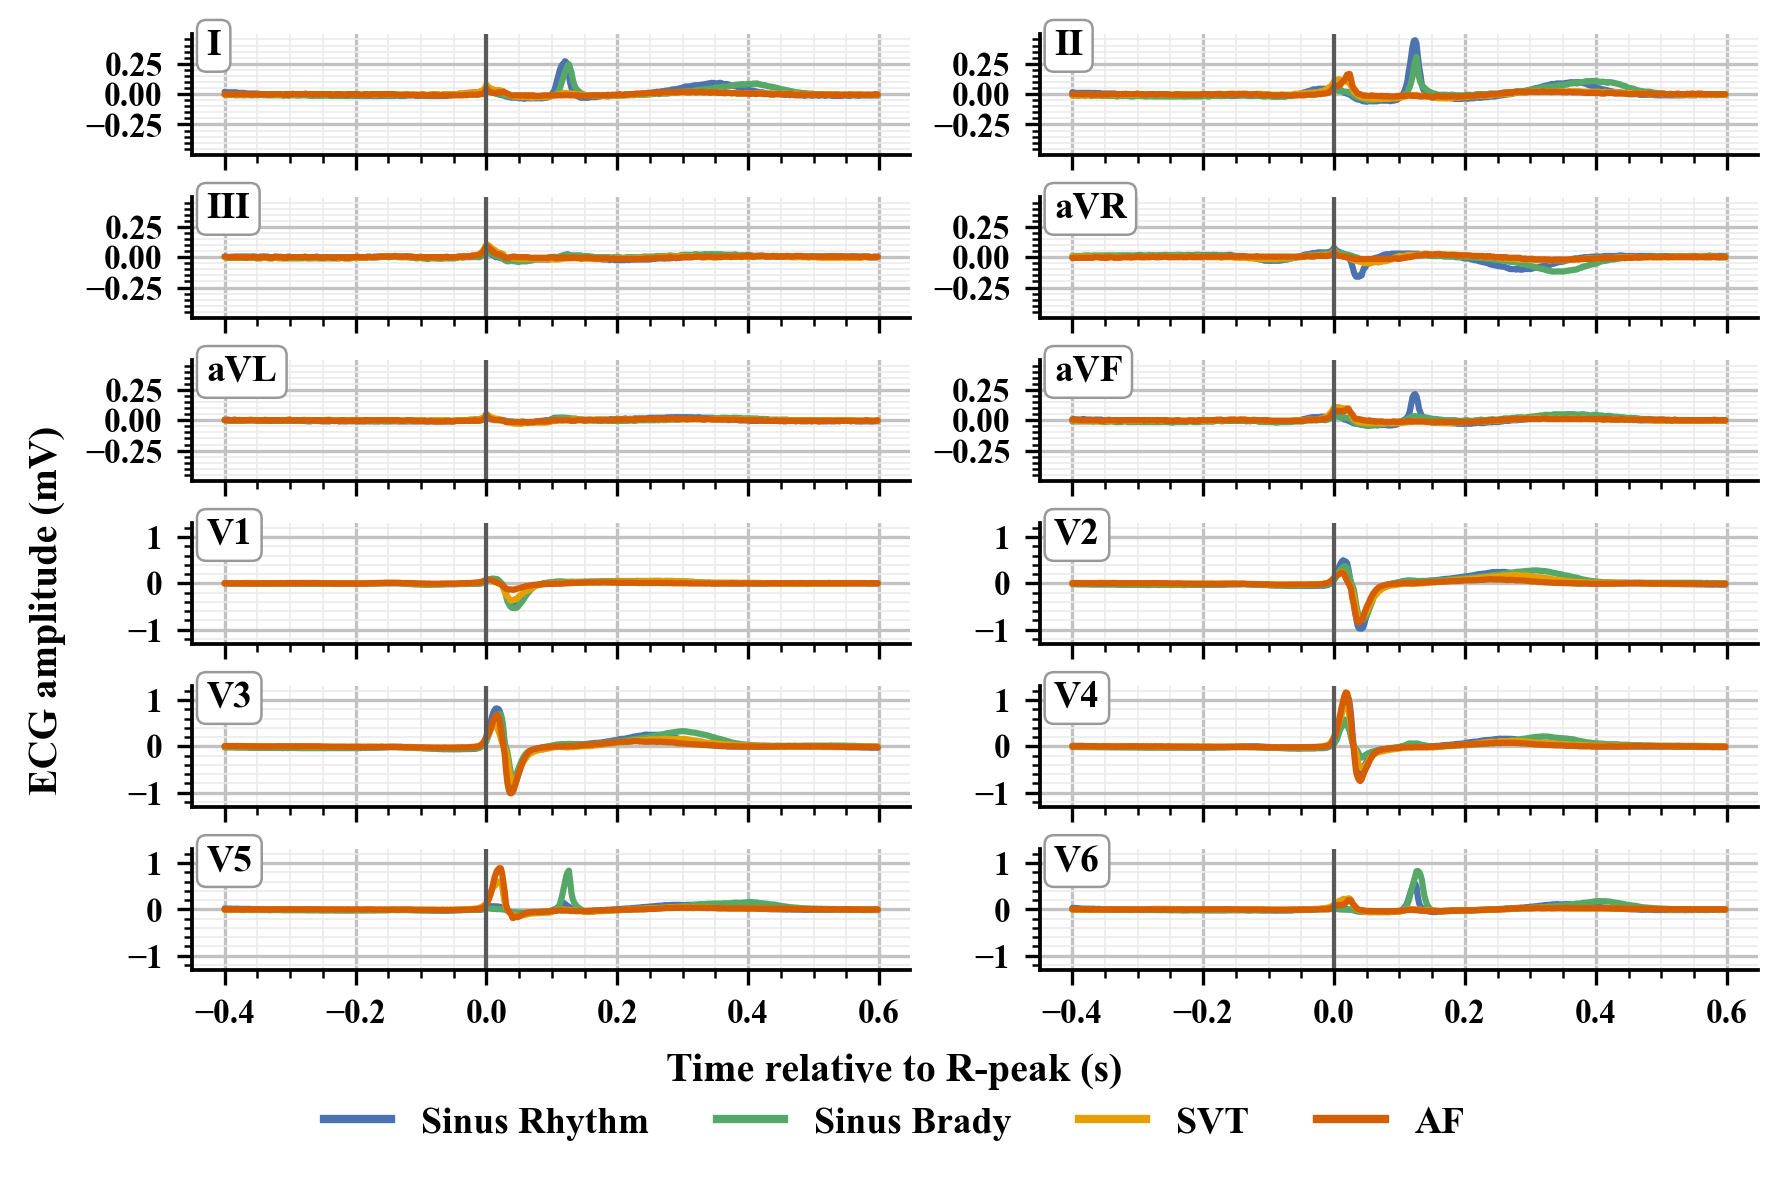

In [50]:
import numpy as np
import matplotlib.pyplot as plt

rng=np.random.default_rng(0)

COLORS={
    "Sinus Rhythm":"#4C72B0",
    "Sinus Brady":"#55A868",
    "SVT":"#E69F00",
    "AF":"#D55E00",
}

ORDER=["Sinus Rhythm","Sinus Brady","SVT","AF"]

LEAD_LAYOUT=[
"I","II",
"III","aVR",
"aVL","aVF",
"V1","V2",
"V3","V4",
"V5","V6"
]

LIMB={"I","II","III","aVR","aVL","aVF"}

lead_index={l:i for i,l in enumerate(LEAD_NAMES)}
cond_index={l:i for i,l in enumerate(CONDITION_NAMES)}

plt.rcParams.update({
"font.family":"serif",
"font.serif":["Times New Roman","Times","DejaVu Serif"],
"figure.dpi":300,
"axes.spines.top":False,
"axes.spines.right":False,
"axes.linewidth":0.9,
"font.size":8,
"font.weight":"bold"
})

rows=[]
for cond in range(y.shape[1]):
    idx=np.where(y[:,cond])[0]
    if len(idx)==0:continue
    rows.append(rng.choice(idx,size=min(100,len(idx)),replace=False))
rows=np.concatenate(rows)

templates={}
lead_values={l:[] for l in LEAD_LAYOUT}

for lead in LEAD_LAYOUT:

    li=lead_index[lead]

    for cname in ORDER:

        ci=cond_index[cname]
        idx=np.where(y[rows,ci])[0]

        if len(idx)==0:
            templates[(lead,cname)]=None
            continue

        beats=[]

        for r in rows[idx]:

            sig=X[r,li,:]
            sig=sig-np.median(sig)

            rpk=detect_r_peaks(sig,FS)[:MAX_BEATS_PER_RECORD]

            for rp in rpk:

                s=rp-pre
                e=rp+post

                if s<0 or e>=T:
                    continue

                beats.append(sig[s:e])

        if len(beats)==0:
            templates[(lead,cname)]=None
            continue

        beats=np.stack(beats)
        template=np.median(beats,axis=0)

        templates[(lead,cname)]=template
        lead_values[lead].append(template)

limb_vals=[]
chest_vals=[]

for lead in LEAD_LAYOUT:

    waves=np.stack(lead_values[lead])

    if lead in LIMB:
        limb_vals.append(waves)
    else:
        chest_vals.append(waves)

limb_scale=1.12*np.nanmax(np.abs(np.concatenate(limb_vals)))
chest_scale=1.12*np.nanmax(np.abs(np.concatenate(chest_vals)))

fig,axes=plt.subplots(6,2,figsize=(6,4),sharex=True)
axes=axes.flatten()

for i,lead in enumerate(LEAD_LAYOUT):

    ax=axes[i]

    for cname in ORDER:

        m=templates[(lead,cname)]

        if m is None:continue

        ax.plot(
            t_sec,
            m,
            color=COLORS[cname],
            lw=1.5,
            solid_capstyle="round"
        )

    ax.axvline(0,color="0.35",lw=1.0)

    ax.grid(True,color="0.76",lw=0.8)
    ax.minorticks_on()
    ax.grid(which="minor",color="0.92",lw=0.4)

    if lead in LIMB:
        ax.set_ylim(-limb_scale,limb_scale)
    else:
        ax.set_ylim(-chest_scale,chest_scale)

    ax.text(
        0.02,
        0.90,
        lead,
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.6",
            linewidth=0.6
        )
    )

handles=[plt.Line2D([0],[0],color=COLORS[c],lw=2,label=c) for c in ORDER]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,0.03),
    columnspacing=1.8,
    handlelength=1.8
)

fig.supxlabel(
    "Time relative to R-peak (s)",
    y=0.10,
    fontweight="bold"
)

fig.supylabel("ECG amplitude (mV)",fontweight="bold")

plt.subplots_adjust(
left=0.11,
right=0.98,
top=0.98,
bottom=0.20,
hspace=0.35,
wspace=0.18
)

plt.show()

In [33]:
import numpy as np

rng = np.random.default_rng(0)

rows = []
for cond in range(y.shape[1]):
    idx = np.where(y[:, cond])[0]
    if len(idx) == 0:
        continue
    take = min(100, len(idx))
    rows.append(rng.choice(idx, size=take, replace=False))

rows = np.concatenate(rows)

subset = X[rows]  # shape ≈ (≤400, 12, T)

print("Rows sampled:", subset.shape[0])
print()

for lead in range(subset.shape[1]):

    lead_vals = subset[:, lead, :]
    finite = lead_vals[np.isfinite(lead_vals)]

    print(f"Lead {LEAD_NAMES[lead]}")

    if finite.size == 0:
        print("  all values NaN")
    else:
        print("  min :", np.min(finite))
        print("  max :", np.max(finite))
        print("  mean:", np.mean(finite))

    print()

Rows sampled: 400

Lead I
  min : -10.316
  max : 6.998
  mean: 8.8481844e-05

Lead II
  min : -10.097
  max : 8.73
  mean: 0.001944698

Lead III
  min : -3.133
  max : 3.475
  mean: 0.0018528935

Lead aVR
  min : -7.847
  max : 10.209
  mean: 0.00016042165

Lead aVL
  min : -5.27
  max : 2.655
  mean: -0.0020541588

Lead aVF
  min : -4.939
  max : 5.246
  mean: 0.00072767964

Lead V1
  min : -6.573
  max : 2.767
  mean: -0.002119338

Lead V2
  min : -7.061
  max : 5.095
  mean: -0.0012169101

Lead V3
  min : -8.184
  max : 6.817
  mean: 0.00046151018

Lead V4
  min : -5.417
  max : 7.647
  mean: 0.0026134846

Lead V5
  min : -5.958
  max : 7.432
  mean: 0.0003283356

Lead V6
  min : -31.954
  max : 32.767
  mean: -0.00015616666



ValueError: x and y must have same first dimension, but have shapes (500,) and (5000,)

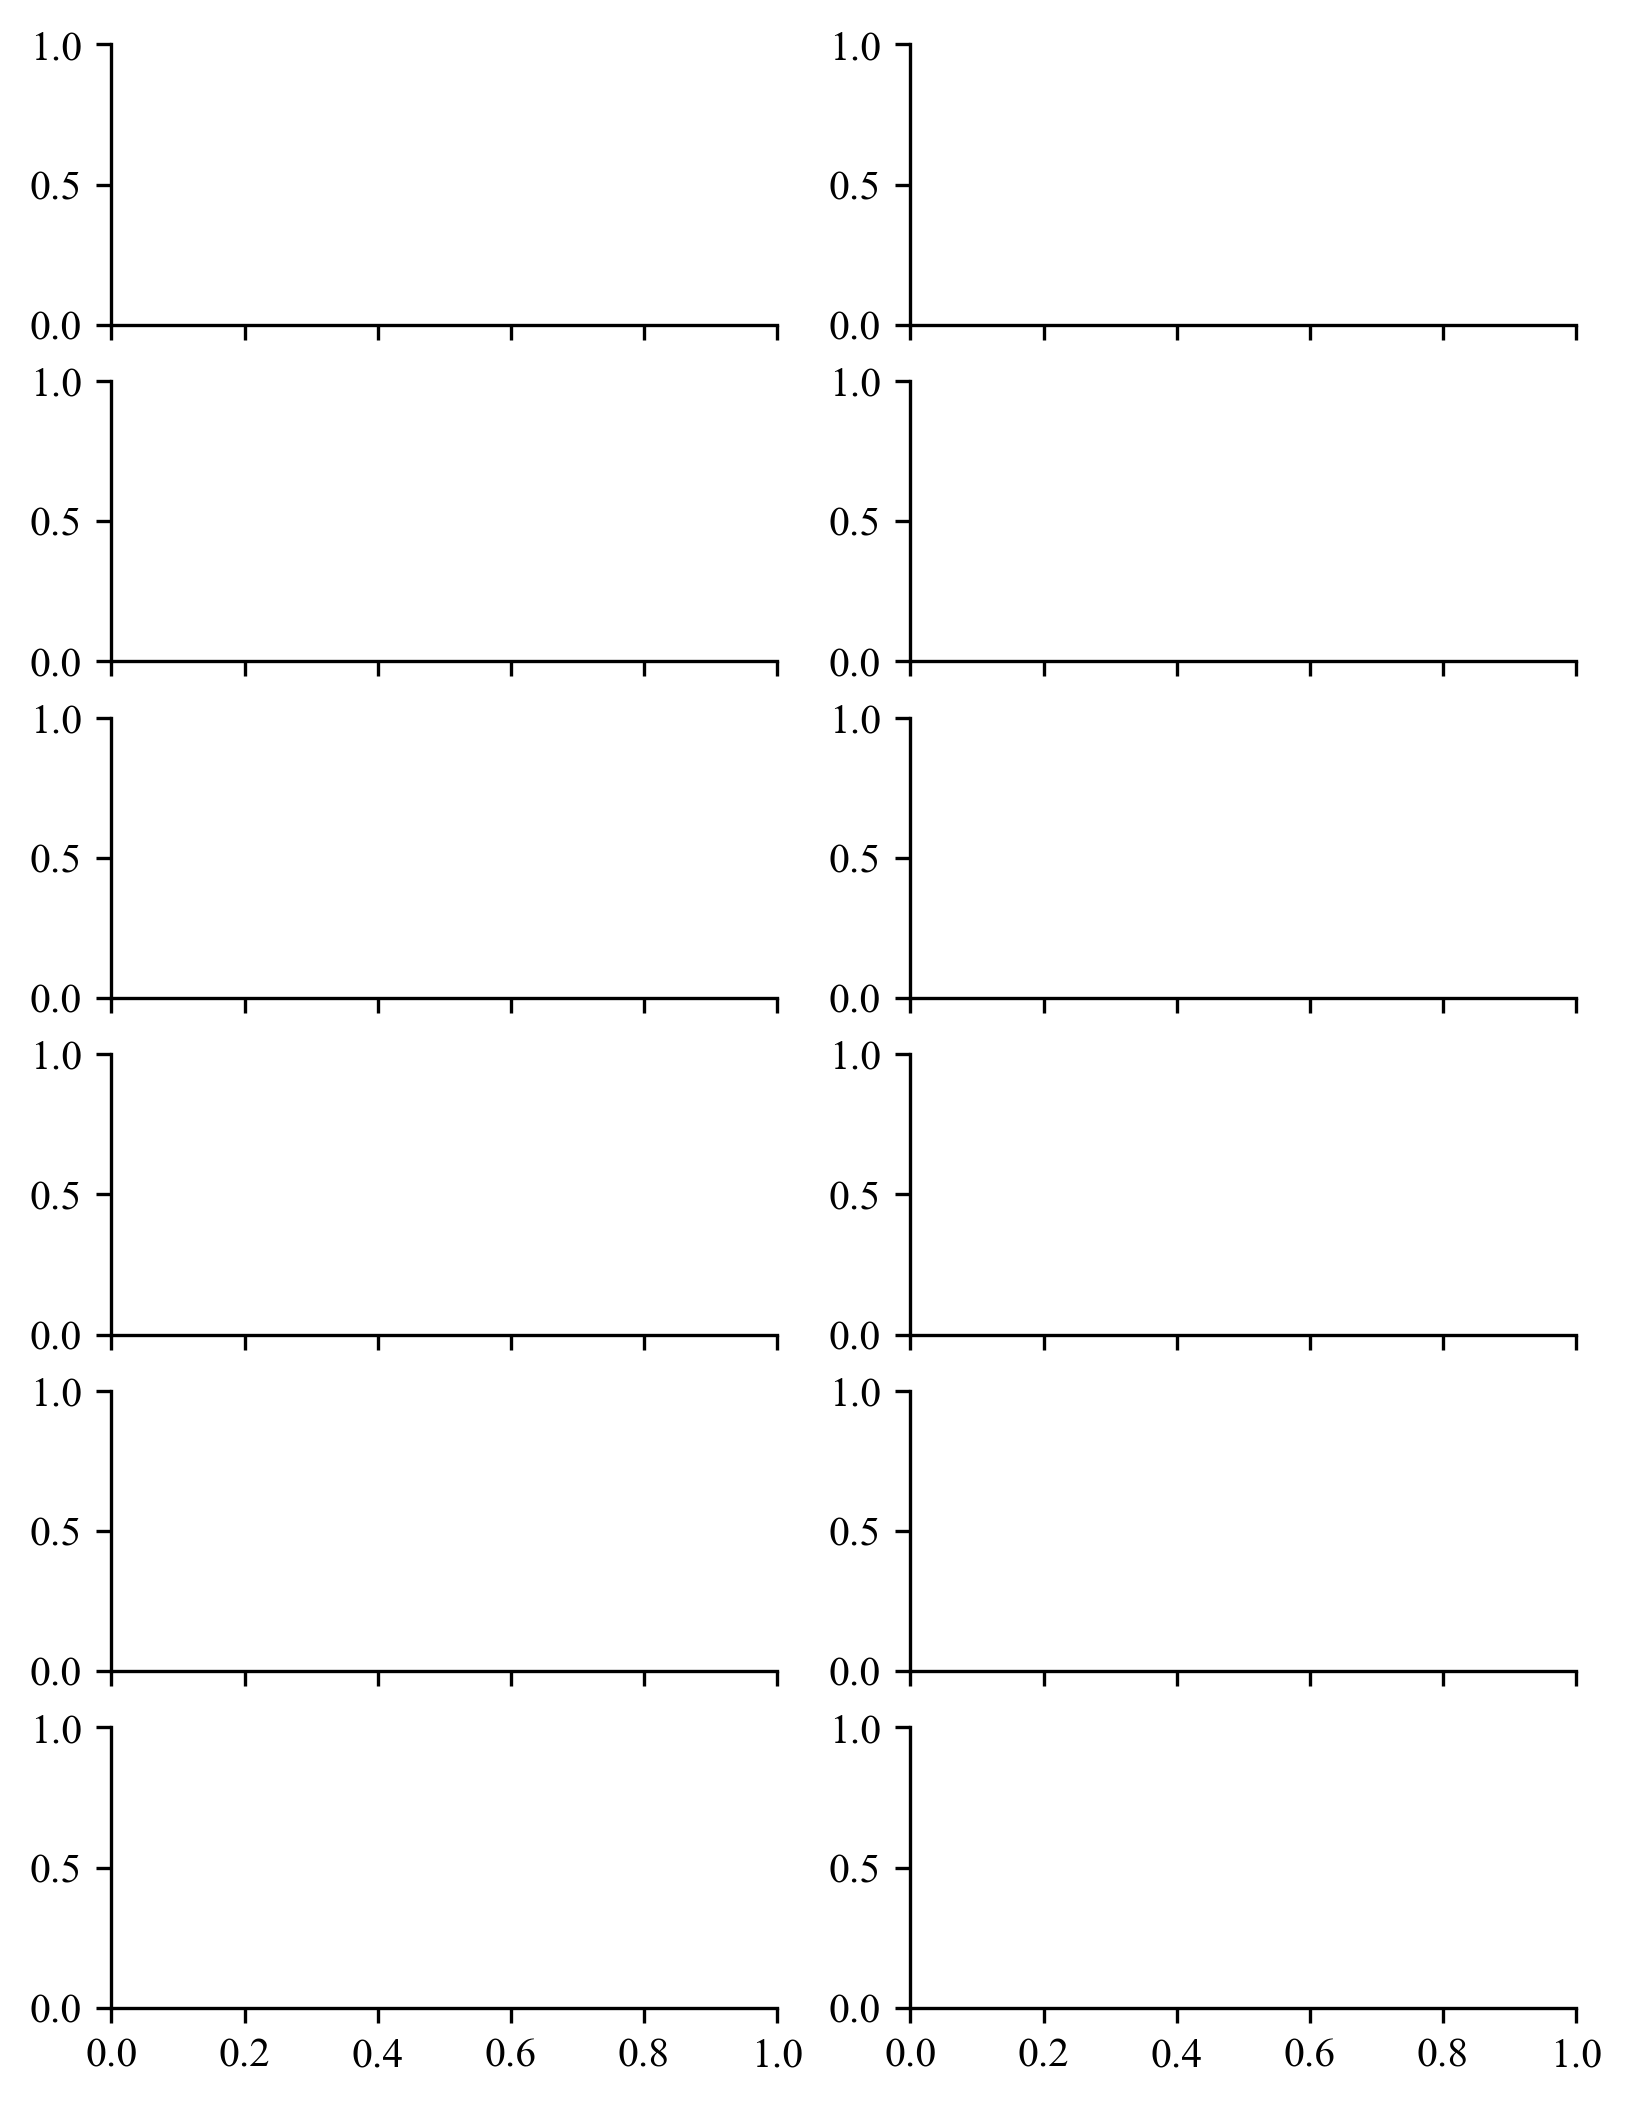

In [38]:
import numpy as np
import matplotlib.pyplot as plt

rng=np.random.default_rng(0)

COLORS={"Sinus Rhythm":"#4C72B0","Sinus Brady":"#55A868","SVT":"#E69F00","AF":"#D55E00"}
ORDER=["Sinus Rhythm","Sinus Brady","SVT","AF"]

LEAD_LAYOUT=["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

lead_index={l:i for i,l in enumerate(LEAD_NAMES)}
cond_index={l:i for i,l in enumerate(CONDITION_NAMES)}

plt.rcParams.update({
"font.family":"serif",
"font.serif":["Times New Roman","Times","DejaVu Serif"],
"axes.spines.top":False,
"axes.spines.right":False,
"axes.linewidth":0.8,
"figure.dpi":300
})

# sample rows (100 per condition)
rows=[]
for cond in range(y.shape[1]):
    idx=np.where(y[:,cond])[0]
    if len(idx)==0:continue
    rows.append(rng.choice(idx,size=min(100,len(idx)),replace=False))
rows=np.concatenate(rows)

subset=X[rows]

templates={}
lead_values={l:[] for l in LEAD_LAYOUT}

for lead in LEAD_LAYOUT:
    li=lead_index[lead]
    for cname in ORDER:
        ci=cond_index[cname]
        idx=np.where(y[rows,ci])[0]
        if len(idx)==0:
            templates[(lead,cname)]=None
            continue
        sig=subset[idx,li,:]
        mean_wave=np.mean(sig,axis=0)   # shape (T,)
        templates[(lead,cname)]=mean_wave
        lead_values[lead].append(mean_wave)

# robust per-lead scaling
lead_ylim={}
for lead in LEAD_LAYOUT:
    vals=np.concatenate(lead_values[lead])
    lead_ylim[lead]=np.percentile(np.abs(vals),99)

# plotting
fig,axes=plt.subplots(6,2,figsize=(6.3,8.5),sharex=True)
axes=axes.flatten()

for i,lead in enumerate(LEAD_LAYOUT):
    ax=axes[i]
    for cname in ORDER:
        m=templates[(lead,cname)]
        if m is None:continue
        ax.plot(t_sec,m,color=COLORS[cname],lw=2)
    ax.axvline(0,color="0.45",lw=0.8)
    ax.grid(True,color="0.85",lw=0.6)
    ax.set_title(lead,pad=2)
    ylim=lead_ylim[lead]
    ax.set_ylim(-ylim,ylim)

fig.supxlabel("Time relative to R-peak (s)")
fig.supylabel("ECG amplitude (mV)")

handles=[plt.Line2D([0],[0],color=COLORS[c],lw=2,label=c) for c in ORDER]
fig.legend(handles=handles,loc="lower center",ncol=4,frameon=False,bbox_to_anchor=(0.5,0.02))

plt.subplots_adjust(left=0.12,right=0.98,top=0.97,bottom=0.10,hspace=0.28,wspace=0.18)

plt.show()